In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
centroids=[(-5,-5),(5,5)]
cluster_std=[1,1]
X,y=make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)

C:\Users\TANUSHREE\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [54]:
import random
class KMeans:
    #decide n clusters
    def __init__(self,n_cluster=2,max_iter=100):
        self.n_cluster=n_cluster
        self.max_iter=max_iter
        self.centroid=None
    def fit_predict(self,X):
        # 1 )initalize centroid randomly from all rows present x=(cgpa,iq),y=0th cluster or 1st cluster
        #centriods are randomly selected 
        #range of centroid selection =0 to no of rows /and no of random centroid to be selected = no of cluster
        random_index=random.sample(range(0,X.shape[0]),self.n_cluster)
        self.centroid=X[random_index]

        for i in range(self.max_iter):#each time we assign cluster on basis of min distance from centroid
            #max_iter helps to reach to best clustring
            # 2 ) assign cluster depending on euclideian distance from centroid
            cluster_group=self.assign_cluster(X)
            # cluster_group will contain [0,1,1,0,0....] each row belong to which cluster
            old_centroid=self.centroid



            
            # 3 ) mover centroid
            self.centroid=self.move_centroid(X,cluster_group)
            
            # 4 ) check finish
            if (old_centroid==self.centroid).all():
                break
        return cluster_group
                
    def assign_cluster(self,X):
        # 2 ) assign cluster depending on euclideian distance from centroid
        cluster_group=[]
        distances=[]
        for row in X:
            for centroid in self.centroid:
                #between the current row and current centroid get euclidean distance
                # eucledian distance =root(x2-x1)^2+(y2-y1)^2 
                #but what if 3 columns are there
                # eucledian distance =root(x2-x1)^2+(y2-y1)^2 +(z2-z1)^2
                # hence we can genralise it by using the dot product
                # [(x2-x1),(y2-y1)] . [(x2-x1)]
                #                     [(y2-y1)]
                #now even if z get added then no problem
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
                
            min_distances=min(distances)
            index_pos=distances.index(min_distances) # either 0 or 1 location which ever is min from centroid
            cluster_group.append(index_pos)


                
                
            distances.clear()
        return np.array(cluster_group)
                #their are 2 centroids so we get distences of each row with both centroid
                #which ever is min distance that point will go to that cluster
                
    def move_centroid(self,X,cluster_group):
        #seperate all 0 and all 1 group and calculate its mean seperately
        new_centroid=[]
        # how many unique cluster??
        cluster_type=np.unique(cluster_group)
        for type in cluster_type:
             #clsuter_group=[0,1,1,0.....]
             #cluster type =0,1
            #sare same cluster walo ka mean lo
            new_centroid.append(X[cluster_group==type].mean(axis=0))
        return np.array(new_centroid)
            
        
        
        
                
                
                


    
    

In [55]:
row=np.array([7,8])
centroid=np.array([5,6])
np.dot(row-centroid,row-centroid)
np.sqrt(np.dot(row-centroid,row-centroid))



np.float64(2.8284271247461903)

In [59]:
km=KMeans(n_cluster=2,max_iter=100)
y_means=km.fit_predict(X)


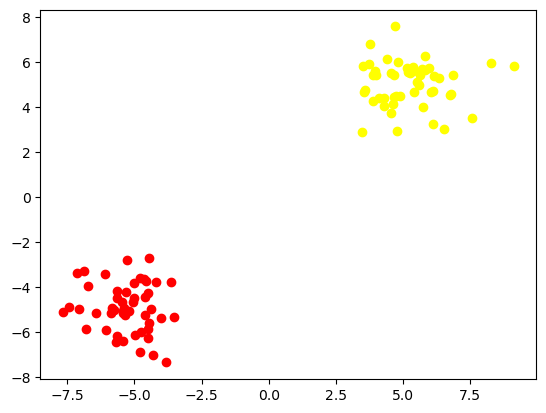

In [65]:
plt.scatter(X[y_means == 0,0],X[y_means==0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means==1,1],color='yellow')

In [62]:
X[y_means==0,0]

array([-5.3135082 , -5.65325027, -4.49711858, -4.30488039, -5.26905696,
       -7.1361961 , -7.04032305, -4.49814279, -4.17529699, -5.46200535,
       -5.67767558, -3.63276458, -4.61813377, -4.44854596, -5.0191305 ,
       -6.42121723, -5.38151648, -6.05795222, -5.03957024, -5.33882197,
       -4.99999024, -6.79343559, -3.99963411, -7.65944946, -5.82913529,
       -4.46094168, -4.61952803, -5.40389227, -4.79579202, -5.74787095,
       -7.43476758, -5.63467931, -4.38865922, -5.37566942, -5.41675785,
       -3.53232199, -4.47570357, -6.7379595 , -4.78388399, -6.09873895,
       -4.95846061, -5.41931648, -5.63765501, -3.8264685 , -5.87810789,
       -5.18946926, -4.62955546, -4.56650367, -6.86809065, -4.74342955])

In [67]:
y

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1])

In [68]:
X

array([[-5.3135082 , -4.22898826],
       [-5.65325027, -4.15754372],
       [-4.49711858, -6.24528809],
       [-4.30488039, -7.03346655],
       [ 5.36505352,  5.77408203],
       [-5.26905696, -2.76863321],
       [-7.1361961 , -3.35972919],
       [ 5.79918   ,  6.26261366],
       [-7.04032305, -4.95374448],
       [ 5.39652016,  4.68538256],
       [ 6.11788673,  4.72575791],
       [ 9.10869262,  5.82112088],
       [-4.49814279, -5.8442137 ],
       [ 5.61014409,  5.4234969 ],
       [ 3.54663565,  4.66198222],
       [ 6.53176032,  3.01415423],
       [ 4.67495037,  4.43976549],
       [-4.17529699, -3.75178708],
       [-5.46200535, -4.64911151],
       [-5.67767558, -6.43943903],
       [-3.63276458, -3.78211437],
       [-4.61813377, -4.43372456],
       [ 4.77175244,  2.93038774],
       [-4.44854596, -2.70779199],
       [ 5.96078194,  5.75837035],
       [-5.0191305 , -3.82499878],
       [ 4.53165374,  3.74527969],
       [-6.42121723, -5.1534952 ],
       [-5.38151648,

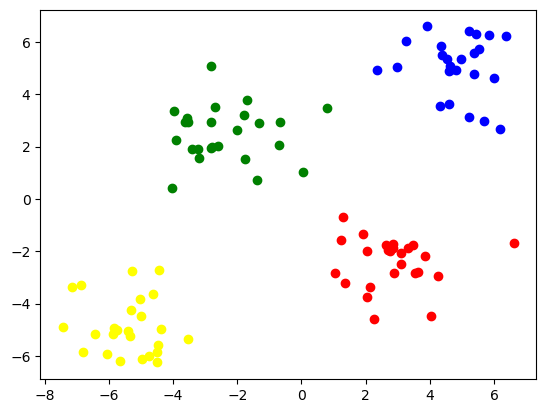

In [82]:
centroids=[(-5,-5),(5,5),(-2.5,2.5),(2.5,-2.5)]

cluster_std=[1,1,1,1]
X,y=make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)
km=KMeans(n_cluster=4,max_iter=1000)
y_means=km.fit_predict(X)
plt.scatter(X[y_means == 0,0],X[y_means==0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means==1,1],color='yellow')
plt.scatter(X[y_means == 2,0],X[y_means==2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means==3,1],color='blue')

In [83]:
!git add .


In [84]:
!git commit -m "my ms"

[main 97dd53a] my ms
 2 files changed, 12 insertions(+)
 create mode 100644 kmeanclustering/.ipynb_checkpoints/Untitled-checkpoint.ipynb
 create mode 100644 kmeanclustering/Untitled.ipynb


In [85]:
!git push origin main

To https://github.com/TANUSHRI-BHISE/LinearRegression.git
   fe6d1f3..97dd53a  main -> main
